## Part 4: Choose your own advecnture! (7 Points; Optional for Extra Credit)

This section is open ended and your chance to explare any advanced analysis. Please perform any additional analysis you find interesting! Suggested analyses (only do one max):

- Word frequency over time - does the frequency of certain words change over time

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-dark') 

In [2]:
sou = pd.read_csv("data/SOTU.csv")
sou

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
...,...,...,...,...
241,George Washington,1791.0,\nFellow-Citizens of the Senate and House of R...,2264
242,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
243,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
244,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069


In [18]:
import re

sou["text_lower"] = sou["Text"].str.lower()

sou["Year"] = pd.to_numeric(sou["Year"], errors="coerce")
sou = sou.dropna(subset=["Year"])
sou["Year"] = sou["Year"].astype(int)

sou[["President", "Year", "Word Count"]].head()

,President,Year,Word Count
0,Joseph R. Biden,2024,8003
1,Joseph R. Biden,2023,8978
2,Joseph R. Biden,2022,7539
3,Joseph R. Biden,2021,7734
4,Donald J. Trump,2020,6169


In [46]:
word_list = ['year',
 'america',
 'people',
 'new',
 'world'] # words from tf-idf

word_list

['year', 'america', 'people', 'new', 'world']

In [47]:
def count_word(text, word):
    pattern = r"\b" + re.escape(word.lower()) + r"\b"
    return len(re.findall(pattern, text))

for w in word_list:
    count_col = f"count_{w}"
    freq_col = f"freq_{w}_per_1000"
    
    sou[count_col] = sou["text_lower"].apply(lambda txt: count_word(txt, w))
    sou[freq_col] = (sou[count_col] / sou["Word Count"]) * 1000

sou[[ "President", "Year"] + [f"freq_{w}_per_1000" for w in word_list]].head()

,President,Year,freq_year_per_1000,freq_america_per_1000,freq_people_per_1000,freq_new_per_1000,freq_world_per_1000
0,Joseph R. Biden,2024,2.249157,5.497938,4.248407,1.624391,2.374110
1,Joseph R. Biden,2023,2.895968,4.121185,4.343952,2.227668,2.784585
2,Joseph R. Biden,2022,3.714020,5.703674,3.979308,2.520228,3.448733
3,Joseph R. Biden,2021,1.810189,7.240755,5.042669,1.034394,3.749677
4,Donald J. Trump,2020,2.593613,6.159831,3.566218,3.890420,2.755714


In [48]:
freq_cols = [f"freq_{w}_per_1000" for w in word_list]

yearly_freq = (
    sou.groupby("Year")[freq_cols]
    .mean()
    .reset_index()
    .sort_values("Year")
)

yearly_freq.head()

,Year,freq_year_per_1000,freq_america_per_1000,freq_people_per_1000,freq_new_per_1000,freq_world_per_1000
0,1790,0.000000,0.0,2.806361,0.935454,0.000000
1,1791,0.883392,0.0,0.883392,1.766784,0.000000
2,1792,1.451379,0.0,0.000000,0.967586,0.000000
3,1793,1.029866,0.0,1.029866,1.029866,0.514933
4,1794,0.346500,0.0,0.693001,0.693001,0.346500


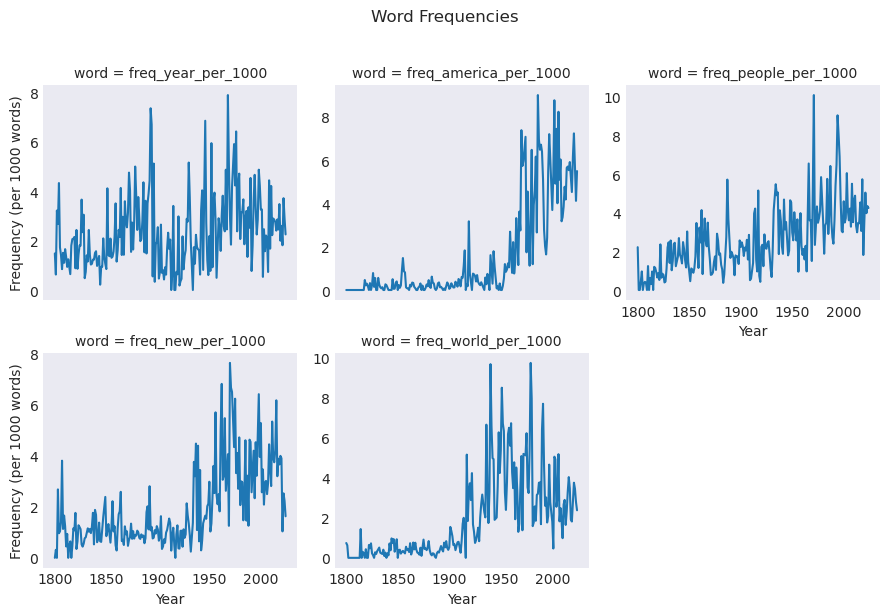

In [53]:
df_long = yearly_modern.melt(
    id_vars="Year",
    value_vars=freq_cols,
    var_name="word",
    value_name="freq_per_1000",
)
g = sns.relplot(
    data=df_long,
    x="Year",
    y="freq_per_1000",
    kind="line",
    hue=None,
    col="word",
    col_wrap=3,
    facet_kws={"sharey": False},
    height=3,
)

g.set_ylabels("Frequency (per 1000 words)")
g.set_xlabels("Year")
g.fig.suptitle("Word Frequencies", y=1.02)
plt.tight_layout()

plt.savefig("word_frequency.png", dpi=300, bbox_inches="tight")

plt.show()